In [2]:
import pandas as pd

# Dosyaları oku
import pandas as pd

df1 = pd.read_excel('2002-2017.xlsx') 


df2 = pd.read_excel('2018-2024.xlsx') 


# İlk iki sütuna isim verelim
# (Snippet'larına bakarak ilk sütunu 'Kategori', ikinciyi 'Banka' varsayıyorum)
def clean_columns(df):
    df.columns.values[0] = 'Category'
    df.columns.values[1] = 'Bank'
    # Kategori sütunundaki boşlukları (merged cells) üstteki değerle doldur
    df['Category'] = df['Category'].ffill()
    return df

df1 = clean_columns(df1)
df2 = clean_columns(df2)

In [3]:
import pandas as pd
import numpy as np

# 1. VERİYİ YÜKLE
df = pd.read_csv('Banka_Makro_Final.csv')

# İlgilendiğimiz değişkenleri seçelim
degiskenler = ['ROA', 'Size', 'NIC_A', 'GDP', 'INF', 'EXC']

# 2. TEMEL İSTATİSTİKLER TABLOSUNU OLUŞTUR
# describe() fonksiyonu count, mean, std, min, max değerlerini verir.
desc_stats = df[degiskenler].describe().T

# Akademik analizlerde verinin normal dağılıp dağılmadığını anlamak için
# Çarpıklık (Skewness) ve Basıklık (Kurtosis) da eklenir.
desc_stats['skewness'] = df[degiskenler].skew()
desc_stats['kurtosis'] = df[degiskenler].kurt()

# Tabloyu daha okunabilir hale getirelim (Gereksiz %25, %75'i atıp önemli olanları alalım)
final_table = desc_stats[['count', 'mean', 'std', 'min', 'max', 'skewness', 'kurtosis']]

# Sütun isimlerini Türkçe yapalım (Rapor için hazır olsun)
final_table.columns = ['Gözlem Sayısı', 'Ortalama', 'Std. Sapma', 'Min', 'Max', 'Çarpıklık', 'Basıklık']

print("--- TABLO 1: TANIMLAYICI İSTATİSTİKLER ---")
print(final_table)


--- TABLO 1: TANIMLAYICI İSTATİSTİKLER ---
       Gözlem Sayısı   Ortalama  Std. Sapma       Min        Max  Çarpıklık  \
ROA           1019.0   0.025259    0.053958 -0.406659   0.365189  -0.007167   
Size          1019.0  15.550561    2.667658  8.120886  22.406857   0.010798   
NIC_A         1019.0   0.014287    0.038463 -0.029478   0.522817   8.611217   
GDP           1019.0   5.443030    3.586386 -4.882694  11.811094  -0.586064   
INF            937.0  18.813887   19.623917  6.250977  72.308836   1.786839   
EXC           1019.0   6.249545    8.481219  1.292908  32.792145   2.079963   

        Basıklık  
ROA    16.264530  
Size   -0.505131  
NIC_A  89.759770  
GDP     0.923991  
INF     1.564942  
EXC     3.219060  


In [4]:
# 'how="outer"' kullanarak her iki dosyada olan tüm bankaları ve kategorileri koruyoruz
merged_df = pd.merge(df1, df2, on=['Category', 'Bank'], how='outer')

# Sonucu kontrol et
print(merged_df.head())

  Category                        Bank        2002          2003        2004  \
0   Assets               Akbank T.A.Ş.  24452559.0  2.948426e+07  34913412.0   
1   Assets  Aktif Yatırım Bankası A.Ş.     58352.0  6.729600e+04     72676.0   
2   Assets         Alternatifbank A.Ş.   1247543.0  1.167466e+06   1174332.0   
3   Assets            Anadolubank A.Ş.   1142887.0  1.561615e+06   1944231.0   
4   Assets      Arap Türk Bankası A.Ş.    290641.0  2.966410e+05    330555.0   

         2005        2006        2007        2008        2009  ...  \
0  52384532.0  57272590.0  68204750.0  85655014.0  95309463.0  ...   
1     64199.0     66792.0    111680.0    251680.0    578047.0  ...   
2   1470292.0   1972076.0   2596962.0   3745007.0   3628804.0  ...   
3   2066819.0   2766464.0   3029698.0   3383765.0   3829037.0  ...   
4    361197.0    372818.0    356689.0    799199.0    965839.0  ...   

          2015         2016         2017         2018         2019  \
0  234808988.0  271016470.0 

In [5]:
# Veriyi CSV dosyası olarak diske kaydediyoruz
merged_df.to_csv('Birlesmis_Banka_Verileri_2002_2024.csv', index=False, encoding='utf-16')

print("Dosya başarıyla oluşturuldu! Şimdi sol taraftaki listede görebilirsiniz.")

Dosya başarıyla oluşturuldu! Şimdi sol taraftaki listede görebilirsiniz.


In [6]:
import pandas as pd
import numpy as np

# 1. DOSYAYI OKURKEN ENCODING BELİRTİYORUZ (Hatanın çözümü burası)
df = pd.read_csv('Birlesmis_Banka_Verileri_2002_2024.csv', encoding='utf-16')

# 2. SEKTÖR TOPLAMLARINI (Gereksiz satırlar) SİLİYORUZ
sektor_toplamlari = [
    'Mevduat Bankaları', 'Kamusal Sermayeli Mevduat Bankaları',
    'Özel Sermayeli Mevduat Bankaları', 'Yabancı Sermayeli Bankalar',
    'Tasarruf Mevduatı Sigorta Fonuna Devredilen Bankalar',
    'Kalkınma ve Yatırım Bankaları', 'Katılım Bankaları'
]
df = df[~df['Bank'].str.strip().isin(sektor_toplamlari)].copy()

# 3. VERİYİ ANALİZ FORMATINA (LONG FORMAT) ÇEVİRİYORUZ
yillar = [str(y) for y in range(2002, 2025)]
df_long = df.melt(id_vars=['Category', 'Bank'], value_vars=yillar, var_name='Year', value_name='Value')

# Kategorileri (Assets, NetProfit, NIC) sütunlara dağıtıyoruz
df_final = df_long.pivot_table(index=['Bank', 'Year'], columns='Category', values='Value', aggfunc='first').reset_index()

# 4. YENİ DEĞİŞKENLERİ HESAPLIYORUZ
# ROA = NetProfit / Assets
df_final['ROA'] = df_final['NetProfit'] / df_final['Assets']

# SIZE = ln(Assets)
df_final['Size'] = np.log(df_final['Assets'].where(df_final['Assets'] > 0))

# NIC_A = NIC / Assets
df_final['NIC_A'] = df_final['NIC'] / df_final['Assets']

# 5. TEMİZLİK KONTROLLERİ
# Assets > 0 olmalı
df_final = df_final[df_final['Assets'] > 0]

# ROA uç değerleri temizle (-0.5 ile 0.5 arası)
df_final = df_final[(df_final['ROA'] < 0.5) & (df_final['ROA'] > -0.5)]

# Banka-Yıl bazında tekrar eden satır varsa sil
df_final = df_final.drop_duplicates(subset=['Bank', 'Year'])

# 6. SÜTUNLARI SIRALAYALIM
standart_sutunlar = ['Bank', 'Year', 'Assets', 'NetProfit', 'NIC', 'ROA', 'Size', 'NIC_A']
df_final = df_final[standart_sutunlar]

# 7. SONUCU YENİ BİR DOSYA OLARAK KAYDEDELİM
df_final.to_csv('Banka_Analiz_Data_Son.csv', index=False, encoding='utf-16')

print("İşlem başarıyla tamamlandı! 'Banka_Analiz_Data_Son.csv' dosyası oluşturuldu.")
print(df_final.head())

İşlem başarıyla tamamlandı! 'Banka_Analiz_Data_Son.csv' dosyası oluşturuldu.
Category           Bank  Year      Assets  NetProfit       NIC       ROA  \
0         Akbank T.A.Ş.  2002  24452559.0   685448.0  110008.0  0.028032   
1         Akbank T.A.Ş.  2003  29484259.0  1324524.0  197032.0  0.044923   
2         Akbank T.A.Ş.  2004  34913412.0  1020528.0  426569.0  0.029230   
3         Akbank T.A.Ş.  2005  52384532.0  1438294.0  636367.0  0.027456   
4         Akbank T.A.Ş.  2006  57272590.0  1600192.0  806921.0  0.027940   

Category       Size     NIC_A  
0         17.012245  0.004499  
1         17.199367  0.006683  
2         17.368382  0.012218  
3         17.774122  0.012148  
4         17.863333  0.014089  


In [7]:
import pandas as pd
import numpy as np

# 1. Dosyaları yüklüyoruz
df_exc = pd.read_excel('macro_exc.xlsx')
df_growth = pd.read_excel('macro_growth.xlsx')
df_inf = pd.read_excel('macro_inflation.xlsx')

# 2. Sütunları seçiyoruz ve isimlerini sadeleştiriyoruz
# Döviz kuru (EXC)
macro_exc = df_exc[['Tarih', 'TP DK USD A YTL']].rename(columns={'Tarih': 'Year', 'TP DK USD A YTL': 'EXC'})
 
# Büyüme (GDP)
macro_growth = df_growth[['Tarih', 'TP GSYIH26 HY ZH-3']].rename(columns={'Tarih': 'Year', 'TP GSYIH26 HY ZH-3': 'GDP'})

# Enflasyon (INF)
macro_inf = df_inf[['Tarih', 'TP FG J0-3']].rename(columns={'Tarih': 'Year', 'TP FG J0-3': 'INF'})

# 3. Tüm dataları "Year" (Yıl) sütunu üzerinden birleştiriyoruz
macro_combined = pd.merge(macro_growth, macro_inf, on='Year', how='outer')
macro_combined = pd.merge(macro_combined, macro_exc, on='Year', how='outer')

# 4. Veri Temizliği
# 'ND' (No Data) yazan yerleri boş (NaN) değerlerle değiştiriyoruz
macro_combined = macro_combined.replace('ND', np.nan)

# Yıl ve değerleri sayısal formata çeviriyoruz
macro_combined['Year'] = pd.to_numeric(macro_combined['Year'], errors='coerce')
for col in ['GDP', 'INF', 'EXC']:
    macro_combined[col] = pd.to_numeric(macro_combined[col], errors='coerce')

# Boş kalan satırları temizleyip yıla göre sıralıyoruz
macro_combined = macro_combined.dropna(subset=['Year']).sort_values('Year')
macro_combined['Year'] = macro_combined['Year'].astype(int)

# 5. Sonucu kaydediyoruz
macro_combined.to_csv('Makro_Birlesik_Data.csv', index=False, encoding='utf-16')

print("Makro veriler başarıyla birleştirildi!")
print(macro_combined.head())

Makro veriler başarıyla birleştirildi!
   Year       GDP       INF       EXC
0  2002  6.435509       NaN  1.505840
1  2003  5.799093       NaN  1.493068
2  2004  9.925406  8.598262  1.422341
3  2005  9.111577  8.179160  1.340791
4  2006  7.067626  9.597242  1.431107


In [8]:
!pip install linearmodels

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# Veriyi yükleme
df = pd.read_csv('Banka_Makro_Final.csv')

# Yıl ve Banka değişkenlerini index yaparak panel yapısını kurma
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df = df.set_index(['Bank', 'Year'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1019 entries, ('Akbank T.A.Ş.', Timestamp('2002-01-01 00:00:00')) to ('Şekerbank T.A.Ş.', Timestamp('2024-01-01 00:00:00'))
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Assets     1019 non-null   float64
 1   NetProfit  1019 non-null   float64
 2   NIC        1019 non-null   float64
 3   ROA        1019 non-null   float64
 4   Size       1019 non-null   float64
 5   NIC_A      1019 non-null   float64
 6   GDP        1019 non-null   float64
 7   INF        937 non-null    float64
 8   EXC        1019 non-null   float64
dtypes: float64(9)
memory usage: 76.9+ KB
None


Veri Seti Hazır. Gözlem Sayısı: 937
------------------------------

Tanımlayıcı İstatistikler (Raporunuza Tablo Olarak Ekleyin):
            mean        std       min        max
ROA     0.025796   0.052975 -0.406659   0.365189
Size   15.727519   2.626836  8.120886  22.406857
NIC_A   0.014630   0.039965 -0.029478   0.522817
GDP     5.384022   3.733201 -4.882694  11.811094
INF    18.813887  19.623917  6.250977  72.308836
EXC     6.665241   8.722559  1.292908  32.792145


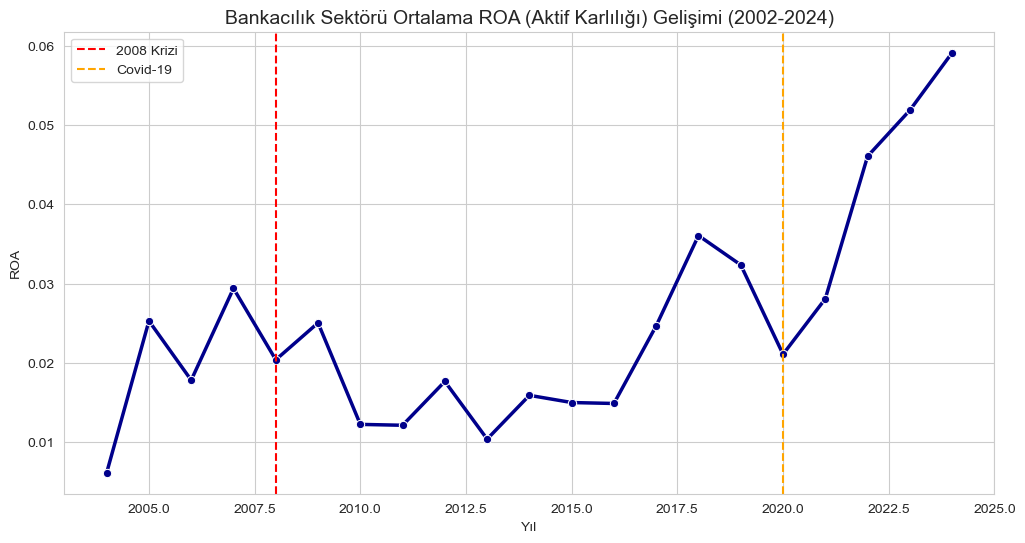

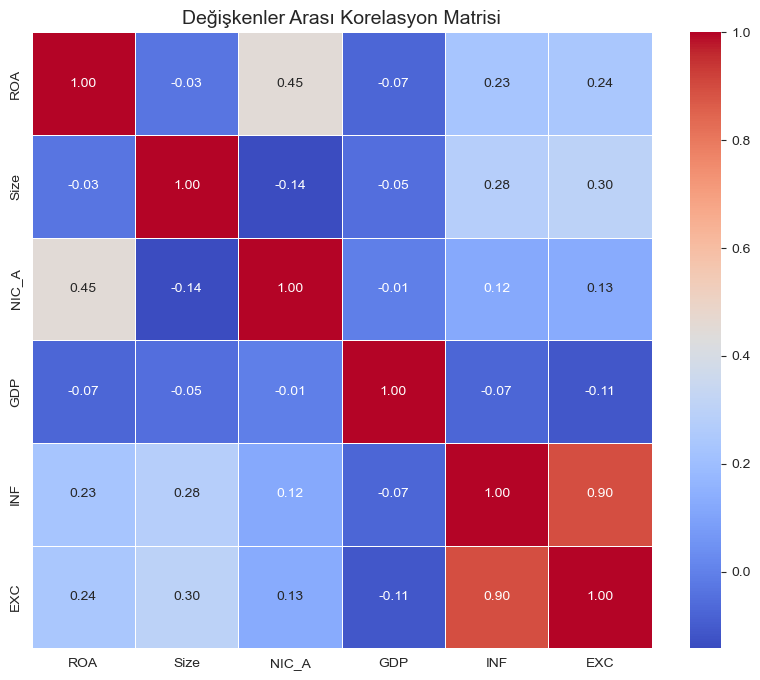

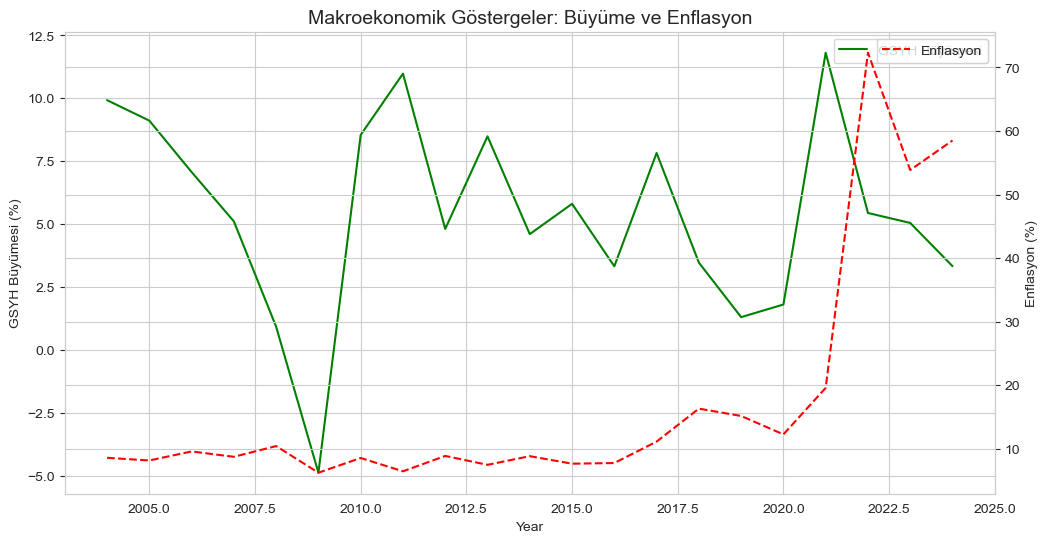


PANEL VERİ REGRESYON SONUÇLARI (Fixed Effects)
                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.2379
Estimator:                   PanelOLS   R-squared (Between):              0.0756
No. Observations:                 937   R-squared (Within):               0.2379
Date:                Mon, Dec 22 2025   R-squared (Overall):              0.2130
Time:                        14:08:02   Log-likelihood                    1727.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      54.814
Entities:                          54   P-value                           0.0000
Avg Obs:                       17.352   Distribution:                   F(5,878)
Min Obs:                       1.0000                                           
Max Obs:                       21.000   F-statistic (robust):

In [10]:
# Gerekli kütüphaneleri yükleyelim
# Eğer yüklü değilse terminalden: pip install pandas seaborn matplotlib linearmodels
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. VERİ YÜKLEME VE DÜZENLEME
# ---------------------------------------------------------
# CSV dosyasını okuyoruz
df = pd.read_csv('Banka_Makro_Final.csv')

# Panel Veri Analizi için veriyi MultiIndex (Banka ve Yıl) yapısına getiriyoruz
# Bu, ekonometrik modelin veriyi "Panel" olarak tanıması için şarttır.
df = df.set_index(['Bank', 'Year'])

# Veri setindeki olası sonsuz veya eksik değerleri temizleyelim
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print("Veri Seti Hazır. Gözlem Sayısı:", len(df))
print("-" * 30)

# ---------------------------------------------------------
# 2. TANIMLAYICI İSTATİSTİKLER (Proje Bölüm 6 - Veri Analizi)
# ---------------------------------------------------------
# Modelde kullanacağımız değişkenleri seçelim
# Bağımlı Değişken: ROA
# Bağımsızlar: Size (Büyüklük), NIC_A (Faiz Dışı Gelir/Varlık), GDP (Büyüme), INF (Enflasyon), EXC (Kur)
vars_of_interest = ['ROA', 'Size', 'NIC_A', 'GDP', 'INF', 'EXC']

desc_stats = df[vars_of_interest].describe().T
print("\nTanımlayıcı İstatistikler (Raporunuza Tablo Olarak Ekleyin):")
print(desc_stats[['mean', 'std', 'min', 'max']])

# ---------------------------------------------------------
# 3. GÖRSELLEŞTİRME (Proje Bölüm 6 - Grafikler)
# ---------------------------------------------------------

# Grafik ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Grafik 1: Yıllara Göre Ortalama ROA (Sektör Karlılığı)
# Referans makaledeki gibi kriz dönemlerini (2008, 2020 vb.) yorumlamak için bu grafik şart.
plt.figure()
mean_roa = df.groupby('Year')['ROA'].mean()
sns.lineplot(x=mean_roa.index, y=mean_roa.values, marker='o', linewidth=2.5, color='darkblue')
plt.title('Bankacılık Sektörü Ortalama ROA (Aktif Karlılığı) Gelişimi (2002-2024)', fontsize=14)
plt.ylabel('ROA')
plt.xlabel('Yıl')
plt.axvline(x=2008, color='red', linestyle='--', label='2008 Krizi') # Kriz çizgisi
plt.axvline(x=2020, color='orange', linestyle='--', label='Covid-19') # Pandemi çizgisi
plt.legend()
plt.show()

# Grafik 2: Korelasyon Isı Haritası (Heatmap)
# Değişkenler arasındaki ilişkinin yönünü gösterir (Örn: Enflasyon artarsa ROA ne olur?)
plt.figure(figsize=(10, 8))
corr_matrix = df[vars_of_interest].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Değişkenler Arası Korelasyon Matrisi', fontsize=14)
plt.show()

# Grafik 3: Makro Değişkenlerin Seyri
# Raporunuzda "Dönem içinde makroekonomik görünüm" başlığı altına koyabilirsiniz.
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
df.groupby('Year')['GDP'].mean().plot(ax=ax1, color='green', label='GSYH Büyümesi', legend=True)
df.groupby('Year')['INF'].mean().plot(ax=ax2, color='red', linestyle='--', label='Enflasyon', legend=True)
ax1.set_ylabel('GSYH Büyümesi (%)')
ax2.set_ylabel('Enflasyon (%)')
plt.title('Makroekonomik Göstergeler: Büyüme ve Enflasyon', fontsize=14)
plt.show()

# ---------------------------------------------------------
# 4. EKONOMETRİK MODEL (Proje Bölüm 6 - Model Sonuçları)
# ---------------------------------------------------------
# Referans makaledeki gibi Makro ve Banka içi değişkenlerin etkisini ölçüyoruz.

# Bağımlı Değişken
Y = df['ROA']

# Bağımsız Değişkenler (Sabit terim ekliyoruz)
X = df[['Size', 'NIC_A', 'GDP', 'INF', 'EXC']]
X = sm.add_constant(X)

# Sabit Etkiler Modeli (Fixed Effects) - Entity Effects=True
# Bu model her bankanın kendine has özelliklerini (alpha_i) dikkate alır.
model = PanelOLS(Y, X, entity_effects=True)
results = model.fit(cov_type='clustered', cluster_entity=True) # Hata terimleri banka bazında kümelenmiş (robust)

print("\n" + "="*50)
print("PANEL VERİ REGRESYON SONUÇLARI (Fixed Effects)")
print("="*50)
print(results)

# ---------------------------------------------------------
# 5. SONUÇLARIN YORUMLANMASI (Otomatik Yorum Üretici)
# ---------------------------------------------------------
print("\n--- ÖZET YORUM (Raporunuzun Sonuç Kısmı İçin İpuçları) ---")
print(f"R-Kare (R-squared): {results.rsquared:.4f} -> Model, banka karlılığındaki değişimin %{results.rsquared*100:.2f}'sini açıklamaktadır.")

p_values = results.pvalues
params = results.params

if p_values['Size'] < 0.05:
    yon = "pozitif" if params['Size'] > 0 else "negatif"
    print(f"- Banka Büyüklüğü (Size), karlılık üzerinde istatistiksel olarak anlamlı ve {yon} etkiye sahiptir.")
else:
    print("- Banka Büyüklüğünün karlılık üzerinde istatistiksel olarak anlamlı bir etkisi bulunamamıştır (Makaledeki 'Too Big to Fail' tartışmasına atıf yapabilirsiniz).")

if p_values['INF'] < 0.05:
    print("- Enflasyonun banka karlılığı üzerinde anlamlı bir etkisi vardır.")
else:
    print("- Enflasyonun bu modelde karlılık üzerinde belirleyici bir etkisi görülmemiştir.")

print(f"- Faiz dışı gelirlerin (NIC_A) katsayısı: {params['NIC_A']:.4f}. Genellikle pozitif olması beklenir (Gelir çeşitlendirmesi hipotezi).")

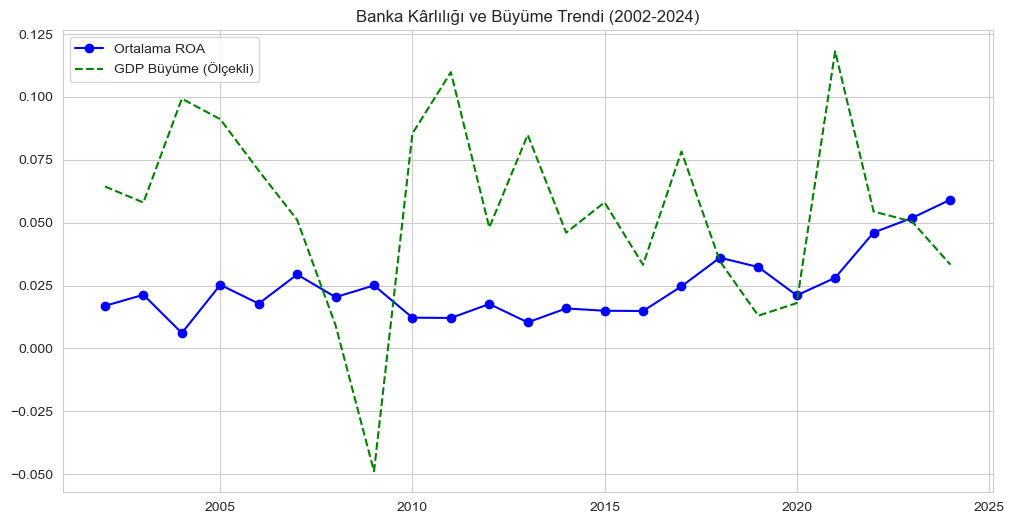

--- Regresyon Sonuçları (Ana Değişkenler) ---
<table class="simpletable">
<tr>
                          <td></td>                             <th>coef</th>     <th>std err</th>      <th>t</th>      <th>P>|t|</th>  <th>[0.025</th>    <th>0.975]</th>  
</tr>
<tr>
  <th>const</th>                                             <td>   -0.0345</td> <td>    0.028</td> <td>   -1.247</td> <td> 0.213</td> <td>   -0.089</td> <td>    0.020</td>
</tr>
<tr>
  <th>Size</th>                                              <td>    0.0026</td> <td>    0.001</td> <td>    1.854</td> <td> 0.064</td> <td>   -0.000</td> <td>    0.005</td>
</tr>
<tr>
  <th>NIC_A</th>                                             <td>    0.5158</td> <td>    0.040</td> <td>   13.025</td> <td> 0.000</td> <td>    0.438</td> <td>    0.594</td>
</tr>
<tr>
  <th>GDP</th>                                               <td>   -0.0008</td> <td>    0.000</td> <td>   -2.227</td> <td> 0.026</td> <td>   -0.002</td> <td>-9.87e-05</td>
</tr>
<tr>
 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Veriyi Yükleme ve Hazırlık
df = pd.read_csv('Banka_Makro_Final.csv')

# Eksik verileri temizleme (Özellikle 2002-2003 INF verileri için)
reg_data = df.dropna(subset=['ROA', 'Size', 'NIC_A', 'GDP', 'INF', 'EXC']).copy()

# Kriz Kukla Değişkeni (2008 Küresel Kriz ve 2020 Pandemi)
reg_data['Crisis'] = reg_data['Year'].apply(lambda x: 1 if x in [2008, 2020] else 0)

# 2. Görselleştirme: Zaman Serisi Analizi
df_yearly = df.groupby('Year').agg({'ROA': 'mean', 'GDP': 'mean', 'INF': 'mean'}).reset_index()
plt.figure(figsize=(12, 6))
plt.plot(df_yearly['Year'], df_yearly['ROA'], label='Ortalama ROA', marker='o', color='blue')
plt.plot(df_yearly['Year'], df_yearly['GDP']/100, label='GDP Büyüme (Ölçekli)', linestyle='--', color='green')
plt.title('Banka Kârlılığı ve Büyüme Trendi (2002-2024)')
plt.legend()
plt.savefig('karlilik_trend.png')
plt.show()

# 3. Sabit Etkiler (Fixed Effects) Regresyonu
# Banka isimlerinden dummy (kukla) değişkenler oluşturuyoruz
bank_dummies = pd.get_dummies(reg_data['Bank'], prefix='Bank', drop_first=True).astype(float)

# Bağımsız değişkenlerimizi seçiyoruz
X_vars = ['Size', 'NIC_A', 'GDP', 'INF', 'EXC', 'Crisis']
X = reg_data[X_vars]
X = pd.concat([X, bank_dummies], axis=1) # Banka etkilerini ekliyoruz
X = sm.add_constant(X) # Sabit terim ekleme
y = reg_data['ROA']

# Modeli kurma ve eğitme
model = sm.OLS(y, X)
results = model.fit()

# Sadece ana değişkenlerin sonuçlarını gösterelim (Banka dummylerini gizleyerek)
print("--- Regresyon Sonuçları (Ana Değişkenler) ---")
print(results.summary().tables[1].as_html()) # Jupyter'de tablo olarak görebilirsin
# Alternatif çıktı:
summary_main = results.params[X_vars + ['const']]
p_values = results.pvalues[X_vars + ['const']]
results_df = pd.DataFrame({'Katsayı': summary_main, 'P-Değeri': p_values})
print(results_df)

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veri Hazırlama
df = pd.read_csv('Banka_Makro_Final.csv')
df = df.sort_values(['Bank', 'Year'])

# Dinamik Panel için Gecikmeli Değişken (ROA_t-1)
df['ROA_lag1'] = df.groupby('Bank')['ROA'].shift(1)
df_clean = df.dropna(subset=['ROA_lag1', 'Size', 'NIC_A', 'GDP', 'INF', 'EXC'])

# 2. Dinamik Panel Regresyonu (LSDV Yöntemi)
# Bağımsız Değişkenler
X_vars = ['ROA_lag1', 'Size', 'NIC_A', 'GDP', 'INF', 'EXC']
X = df_clean[X_vars]
X = sm.add_constant(X)

# Banka bazlı Sabit Etkileri (Fixed Effects) eklemek için dummy değişkenler
bank_dummies = pd.get_dummies(df_clean['Bank'], drop_first=True).astype(float)
X_final = pd.concat([X, bank_dummies], axis=1)

y = df_clean['ROA']

# Modelin Tahmin Edilmesi
model = sm.OLS(y, X_final).fit()

# Sadece ana değişkenlerin katsayılarını raporlayalım
print("--- DİNAMİK PANEL ANALİZİ SONUÇLARI ---")
summary_table = pd.concat([model.params[X_vars + ['const']], model.pvalues[X_vars + ['const']]], axis=1)
summary_table.columns = ['Katsayı', 'P-Değeri']
print(summary_table)

--- DİNAMİK PANEL ANALİZİ SONUÇLARI ---
           Katsayı      P-Değeri
ROA_lag1  0.353171  1.020340e-28
Size      0.001344  3.090998e-01
NIC_A     0.420009  6.857197e-27
GDP      -0.000434  1.842367e-01
INF       0.000194  1.733865e-01
EXC       0.000354  3.142681e-01
const    -0.019901  4.423380e-01


In [13]:
from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.iv import IV2SLS
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. VERİYİ YÜKLEME VE DÜZENLEME
df = pd.read_csv('Banka_Makro_Final.csv')

# Sonsuz değerleri temizle
df = df.replace([np.inf, -np.inf], np.nan)

# İndeks Ayarı (Panel Veri Formatı)
if 'Bank' in df.columns and 'Year' in df.columns:
    df = df.set_index(['Bank', 'Year'])
df = df.sort_index()

# 2. EKSİK VERİLERİ TEMİZLEME (Uyarıyı Engelleyen Kısım)
# Kullanacağımız değişkenlerde boş veri olan satırları baştan siliyoruz.
degiskenler = ['ROA', 'Size', 'NIC_A', 'GDP', 'INF', 'EXC']
df_clean = df.dropna(subset=degiskenler)

print(f"Analize dahil edilen gözlem sayısı: {len(df_clean)}")
print("-" * 50)

# ------------------------------------------------------------------
# ADIM 3: SABİT ETKİLER MODELİ (FIXED EFFECTS)
# ------------------------------------------------------------------
print("\n=== SABİT ETKİLER MODELİ SONUÇLARI ===")
X_fe = sm.add_constant(df_clean[['Size', 'NIC_A', 'GDP', 'INF', 'EXC']])
Y_fe = df_clean['ROA']

# Entity_effects=True ile banka bazlı sabit etkiler
mod_fe = PanelOLS(Y_fe, X_fe, entity_effects=True)
res_fe = mod_fe.fit(cov_type='clustered', cluster_entity=True) 
print(res_fe)

# ------------------------------------------------------------------
# ADIM 4: DİNAMİK PANEL ANALİZİ (GMM / IV Yaklaşımı)
# ------------------------------------------------------------------
print("\n=== DİNAMİK PANEL (GMM/IV) SONUÇLARI ===")

# Gecikmeli değişkenleri ana veri seti üzerinden oluşturuyoruz
# (df_clean üzerinden yaparsak yıl atlamaları sorun olabilir, o yüzden df kullanıyoruz)
df['ROA_Lag1'] = df.groupby(level=0)['ROA'].shift(1) # t-1
df['ROA_Lag2'] = df.groupby(level=0)['ROA'].shift(2) # t-2

Analize dahil edilen gözlem sayısı: 937
--------------------------------------------------

=== SABİT ETKİLER MODELİ SONUÇLARI ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                    ROA   R-squared:                        0.2379
Estimator:                   PanelOLS   R-squared (Between):              0.0756
No. Observations:                 937   R-squared (Within):               0.2379
Date:                Mon, Dec 22 2025   R-squared (Overall):              0.2130
Time:                        14:08:02   Log-likelihood                    1727.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      54.814
Entities:                          54   P-value                           0.0000
Avg Obs:                       17.352   Distribution:                   F(5,878)
Min Obs:                       1.0000                      

Model Başarıyla Kuruldu!
                          IV-2SLS Estimation Summary                          
Dep. Variable:                    ROA   R-squared:                      0.3715
Estimator:                    IV-2SLS   Adj. R-squared:                 0.3673
No. Observations:                 912   F-statistic:                    171.34
Date:                Mon, Dec 22 2025   P-value (F-stat)                0.0000
Time:                        14:16:30   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0023     0.0179     0.1269     0.8990     -0.0328      0.0374
Size          -0.0003     0

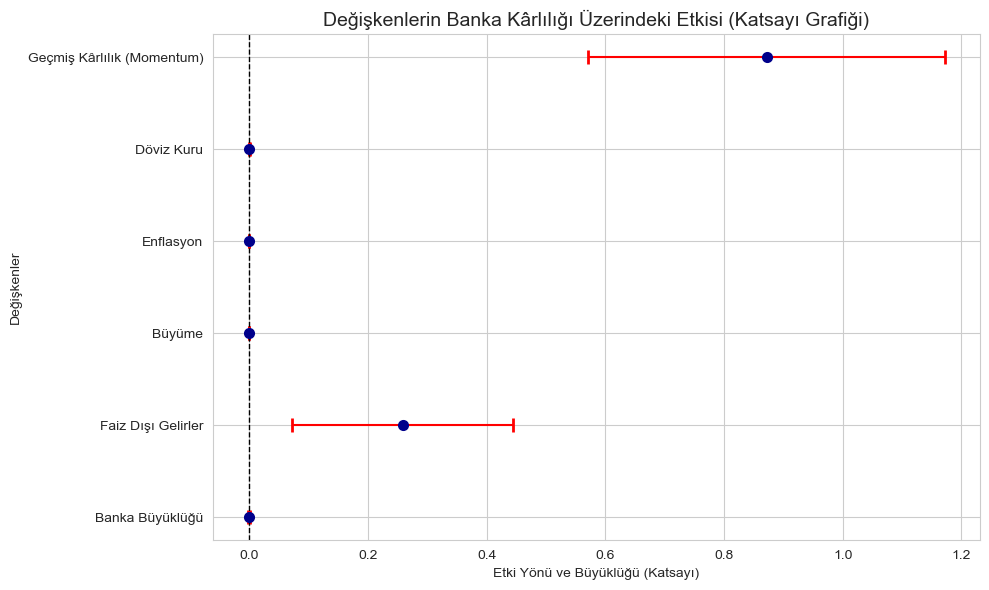

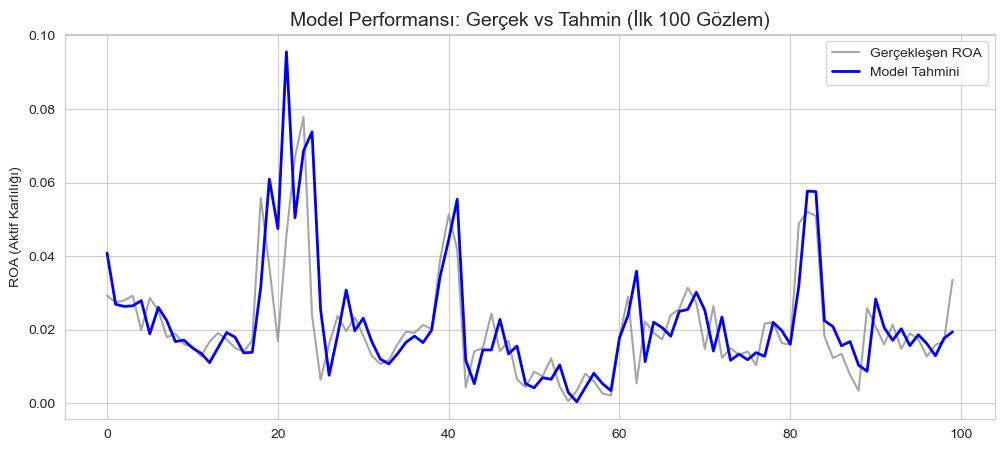

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
from linearmodels.panel import PanelOLS

# ---------------------------------------------------------
# 1. VERİ HAZIRLIĞI VE MODELLEME
# ---------------------------------------------------------

# Veriyi yükle
df = pd.read_csv('Banka_Makro_Final.csv')

# Temizlik
df = df.replace([np.inf, -np.inf], np.nan)
if 'Bank' in df.columns and 'Year' in df.columns:
    df = df.set_index(['Bank', 'Year'])
df = df.sort_index()

# Gecikmeli değişkenleri oluştur (Lag variables)
df['ROA_Lag1'] = df.groupby(level=0)['ROA'].shift(1) # t-1
df['ROA_Lag2'] = df.groupby(level=0)['ROA'].shift(2) # t-2 (Araç)

# Analiz için gerekli sütunlar
cols_needed = ['ROA', 'ROA_Lag1', 'ROA_Lag2', 'Size', 'NIC_A', 'GDP', 'INF', 'EXC']
df_dynamic = df[cols_needed].dropna()

# Değişkenleri Tanımla
Y_dyn = df_dynamic['ROA']
# Bağımsızlar (Lag1 hariç)
X_dyn = sm.add_constant(df_dynamic[['Size', 'NIC_A', 'GDP', 'INF', 'EXC']])
# İçsel Değişken
Endog = df_dynamic['ROA_Lag1']
# Araç Değişken
Instr = df_dynamic[['ROA_Lag2']]

# GMM (IV2SLS) Modelini Kur ve Çalıştır
model_gmm = IV2SLS(Y_dyn, X_dyn, Endog, Instr)
results_gmm = model_gmm.fit()

print("Model Başarıyla Kuruldu!")
print(results_gmm)

# ---------------------------------------------------------
# 2. GÖRSELLEŞTİRME (KATSAYI GRAFİĞİ)
# ---------------------------------------------------------

# Grafik stili
sns.set_style("whitegrid")

# Katsayıları ve hataları çekelim (Sabit terimi atıyoruz)
params = results_gmm.params.drop('const')
errors = results_gmm.std_errors.drop('const')
conf_int = 1.96 * errors # %95 Güven aralığı

plt.figure(figsize=(10, 6))

# Hata çubuklu grafik
plt.errorbar(x=params.values, y=params.index, xerr=conf_int.values, 
             fmt='o', color='darkblue', ecolor='red', capsize=5, markeredgewidth=2)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Değişkenlerin Banka Kârlılığı Üzerindeki Etkisi (Katsayı Grafiği)', fontsize=14)
plt.xlabel('Etki Yönü ve Büyüklüğü (Katsayı)')
plt.ylabel('Değişkenler')

# Etiketleri Türkçeleştirelim
labels_map = {'Size': 'Banka Büyüklüğü', 'NIC_A': 'Faiz Dışı Gelirler', 
              'GDP': 'Büyüme', 'INF': 'Enflasyon', 'EXC': 'Döviz Kuru', 
              'ROA_Lag1': 'Geçmiş Kârlılık (Momentum)'}
new_labels = [labels_map.get(l, l) for l in params.index]
plt.yticks(ticks=range(len(params)), labels=new_labels)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. GÖRSELLEŞTİRME (TAHMİN PERFORMANSI)
# ---------------------------------------------------------

predicted = results_gmm.predict()
actual = Y_dyn

plt.figure(figsize=(12, 5))
# İlk 100 gözlemi alalım ki grafik karışmasın
plt.plot(actual.values[:100], label='Gerçekleşen ROA', color='gray', alpha=0.7)
plt.plot(predicted.values[:100], label='Model Tahmini', color='blue', linewidth=2)

plt.title('Model Performansı: Gerçek vs Tahmin (İlk 100 Gözlem)', fontsize=14)
plt.ylabel('ROA (Aktif Karlılığı)')
plt.legend()
plt.show()